In [123]:
import pandas as pd
import numpy as np  # Import numpy
import matplotlib.pyplot as plt

# Load the CSV data (replace with your actual file path)
file_path = 'Motion_test_data.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the data
print(df.head())


  Accel: x:0.0432586669921875, y:-0.0661163330078125, z:-0.988616943359375
0  Accel: x:0.04425048828125, y:-0.06507873535156...                      
1  Accel: x:0.05035400390625, y:-0.06217956542968...                      
2  Accel: x:0.0440216064453125, y:-0.065536499023...                      
3  Accel: x:0.04296875, y:-0.065643310546875, z:-...                      
4  Accel: x:0.04473876953125, y:-0.06520080566406...                      


In [124]:
print(df.info())  # Get an overview of the DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 1 columns):
 #   Column                                                                    Non-Null Count  Dtype 
---  ------                                                                    --------------  ----- 
 0   Accel: x:0.0432586669921875, y:-0.0661163330078125, z:-0.988616943359375  1058 non-null   object
dtypes: object(1)
memory usage: 8.4+ KB
None


In [125]:
# Split the data into x, y, z values
df[['x_accel', 'y_accel', 'z_accel']] = df['Accel: x:0.0432586669921875, y:-0.0661163330078125, z:-0.988616943359375'].str.extract(r'x:([-\d.]+), y:([-\d.]+), z:([-\d.]+)')

# Convert the columns to numeric type
df['x_accel'] = pd.to_numeric(df['x_accel'])
df['y_accel'] = pd.to_numeric(df['y_accel'])
df['z_accel'] = pd.to_numeric(df['z_accel'])

# Now the DataFrame should have separate x, y, and z columns
print(df.head())

  Accel: x:0.0432586669921875, y:-0.0661163330078125, z:-0.988616943359375  \
0  Accel: x:0.04425048828125, y:-0.06507873535156...                         
1  Accel: x:0.05035400390625, y:-0.06217956542968...                         
2  Accel: x:0.0440216064453125, y:-0.065536499023...                         
3  Accel: x:0.04296875, y:-0.065643310546875, z:-...                         
4  Accel: x:0.04473876953125, y:-0.06520080566406...                         

    x_accel   y_accel   z_accel  
0  0.044250 -0.065079 -0.988861  
1  0.050354 -0.062180 -0.978897  
2  0.044022 -0.065536 -0.989380  
3  0.042969 -0.065643 -0.990265  
4  0.044739 -0.065201 -0.987549  


    x_accel   y_accel   z_accel  accel_magnitude
0  0.044250 -0.065079 -0.988861         0.991988
1  0.050354 -0.062180 -0.978897         0.982162
2  0.044022 -0.065536 -0.989380         0.992525
3  0.042969 -0.065643 -0.990265         0.993368
4  0.044739 -0.065201 -0.987549         0.990710


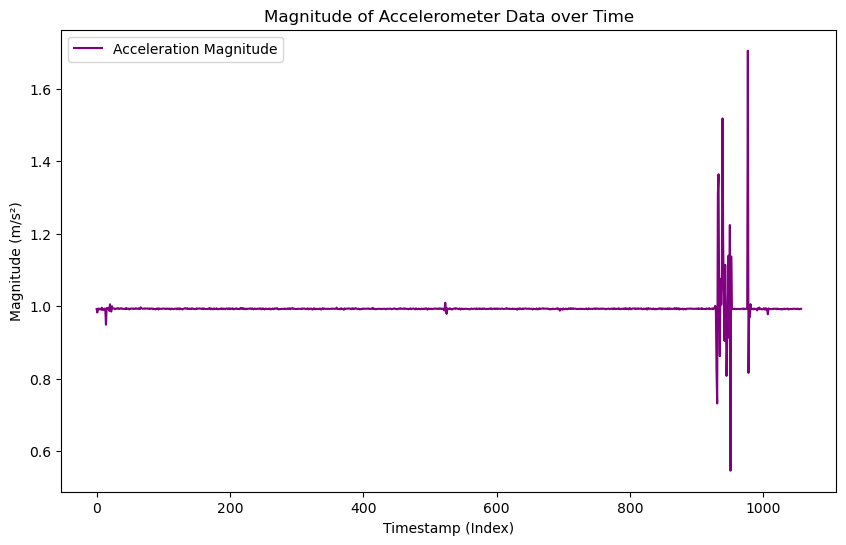

In [126]:
# Calculate magnitude of the accelerometer vector
df['accel_magnitude'] = np.sqrt(df['x_accel']**2 + df['y_accel']**2 + df['z_accel']**2)

# Display the updated DataFrame with magnitude
print(df[['x_accel', 'y_accel', 'z_accel', 'accel_magnitude']].head())

# Visualize the magnitude
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['accel_magnitude'], label='Acceleration Magnitude', color='purple')
plt.xlabel('Timestamp (Index)')
plt.ylabel('Magnitude (m/s²)')
plt.title('Magnitude of Accelerometer Data over Time')
plt.legend()
plt.show()


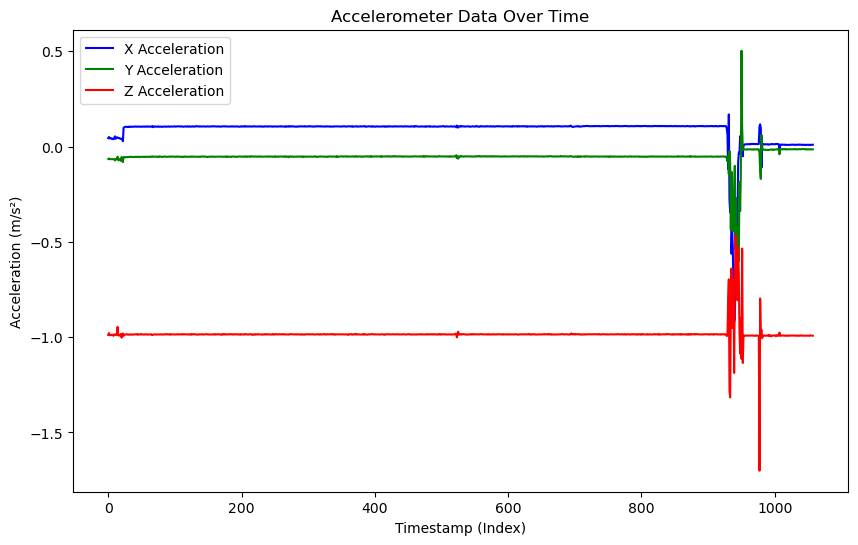

In [127]:
plt.figure(figsize=(10, 6))
plt.plot(df['x_accel'], label='X Acceleration', color='blue')
plt.plot(df['y_accel'], label='Y Acceleration', color='green')
plt.plot(df['z_accel'], label='Z Acceleration', color='red')
plt.xlabel('Timestamp (Index)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Accelerometer Data Over Time')
plt.legend()
plt.show()


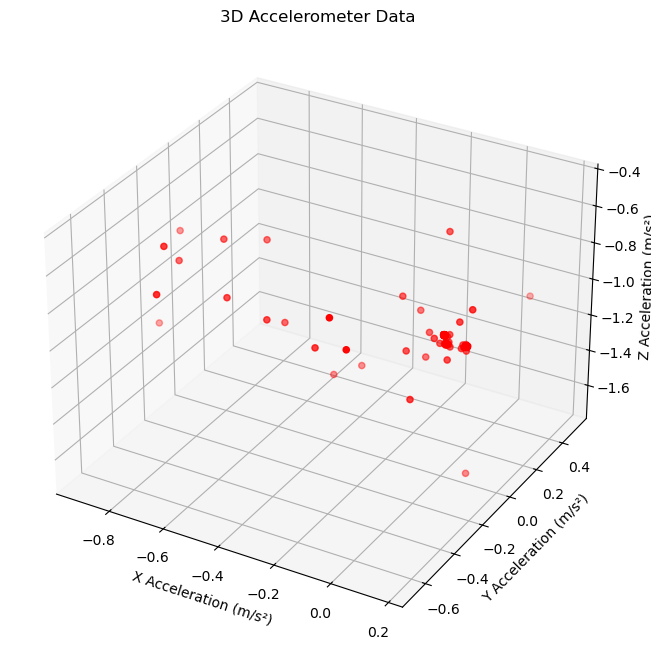

In [128]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['x_accel'], df['y_accel'], df['z_accel'], c='r', marker='o')
ax.set_xlabel('X Acceleration (m/s²)')
ax.set_ylabel('Y Acceleration (m/s²)')
ax.set_zlabel('Z Acceleration (m/s²)')
ax.set_title('3D Accelerometer Data')

plt.show()


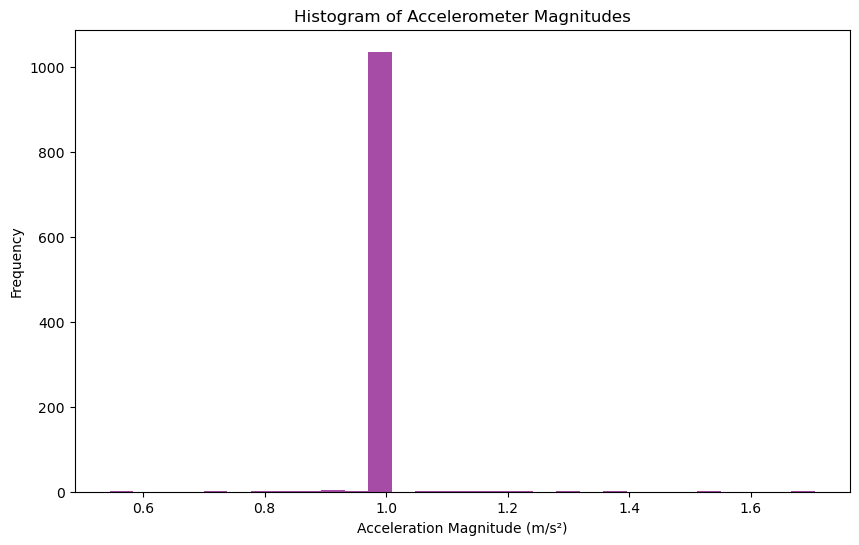

In [129]:
plt.figure(figsize=(10, 6))
plt.hist(df['accel_magnitude'], bins=30, color='purple', alpha=0.7)
plt.xlabel('Acceleration Magnitude (m/s²)')
plt.ylabel('Frequency')
plt.title('Histogram of Accelerometer Magnitudes')
plt.show()


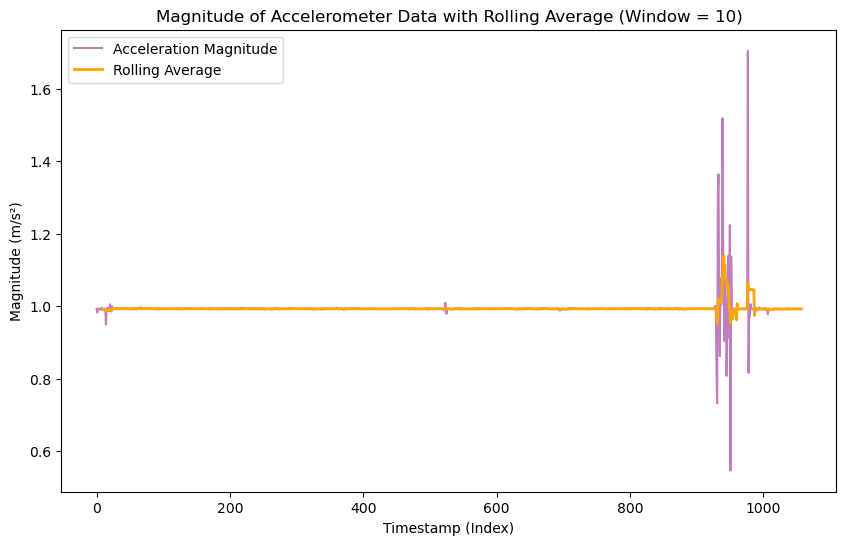

In [130]:
# Calculate rolling average
rolling_window = 10  # Set the window size for the moving average
df['accel_magnitude_rolling'] = df['accel_magnitude'].rolling(window=rolling_window).mean()

# Plot the rolling average
plt.figure(figsize=(10, 6))
plt.plot(df['accel_magnitude'], label='Acceleration Magnitude', color='purple', alpha=0.5)
plt.plot(df['accel_magnitude_rolling'], label='Rolling Average', color='orange', linewidth=2)
plt.xlabel('Timestamp (Index)')
plt.ylabel('Magnitude (m/s²)')
plt.title(f'Magnitude of Accelerometer Data with Rolling Average (Window = {rolling_window})')
plt.legend()
plt.show()
